# Phase 3 — Defining Success in a Current-Snapshot Steam Dataset

**This is a methodological investigation, not a modeling notebook.** No predictive model is trained here.
The question is: *given that this dataset is a single current-day snapshot of ~139K Steam games (no historical
outcome snapshots), can "success" be defined defensibly enough to support supervised modeling in Phase 4 —
and if so, exactly what target, population, and framing survive scrutiny?*

Every section follows: **problem → candidate approaches → evidence → decision.** Rejected approaches are kept
and explained, not deleted — a negative methodological result (e.g. "rolling cohorts don't work here") is as
important a finding as a positive one.

**Standing constraint carried from Phase 1/2:** we do not have `reviews_at_6_months`, `owners_at_12_months`,
launch price, or any other point-in-time historical snapshot. Every outcome field in this dataset
(`estimated_owners`, `positive`/`negative`, `recommendations`, `peak_ccu`, `average_playtime_forever`) is a
**current cumulative value as of the 2026-08-28 snapshot**, not a value observed at any fixed point after
launch. Phase 2 demonstrated this confound directly: Massively Multiplayer games show the *highest* all-time
median review count of any major genre (17) but the *lowest* among 2023-2024 releases (median 1) — the
all-time number is an exposure-time artifact, not a real popularity signal. This notebook exists to work out
how to build around that fact rather than ignore it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import bisect

from audit_utils import load_games, parse_list_field

FIG_DIR = os.path.join('..', 'figures', 'phase3')
os.makedirs(FIG_DIR, exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948'
)
CAT_COLORS = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
TEXT_PRIMARY, TEXT_SECONDARY, GRAY = '#0b0b0b', '#52514e', '#8a8a86'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': TEXT_PRIMARY,
    'text.color': TEXT_PRIMARY, 'xtick.color': TEXT_SECONDARY, 'ytick.color': TEXT_SECONDARY,
    'axes.grid': True, 'grid.color': '#ececea', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    print('saved', path)

def has_item(v, item):
    """genre_list/category_list/etc. survive the parquet round-trip as numpy arrays, not python lists."""
    return hasattr(v, '__iter__') and not isinstance(v, str) and item in v

pd.set_option('display.max_columns', 50)

## Data

Reuse `data/processed/games_clean.parquet` from Phase 2 (normalized genres/categories/developers/publishers,
`total_reviews`, `positive_ratio`, ownership midpoint). This notebook adds full-precision `release_date`
(needed for quarter/rolling cohort comparisons, not present in the Phase 2 table which only kept the year) by
re-reading it from the raw file via `src/audit_utils.py::load_games`, the same parser used throughout the
project — no new parsing logic.

In [2]:
raw = load_games()
games = pd.read_parquet(os.path.join('..', 'data', 'processed', 'games_clean.parquet'))
games['release_date'] = pd.to_datetime(raw['release_date'], errors='coerce')
games['release_quarter'] = games['release_date'].dt.to_period('Q')

SNAPSHOT = pd.Timestamp('2026-08-28')
games['age_days'] = (SNAPSHOT - games['release_date']).dt.days

print(f"games: {games.shape}, snapshot date: {SNAPSHOT.date()}")
games[['app_id', 'release_date', 'release_year', 'total_reviews', 'positive_ratio', 'own_mid']].head(3)

games: (139076, 23), snapshot date: 2026-08-28


,app_id,release_date,release_year,total_reviews,positive_ratio,own_mid
0,856050,2018-05-18,2018.0,0,NaN,10000.0
1,856060,2019-02-02,2019.0,33,0.969697,10000.0
2,856080,2018-10-14,2018.0,17,0.705882,10000.0


---
# 1. Success Is Not One Thing — Separating the Candidate Dimensions

**Problem.** "Success" could mean visibility (lots of players noticed the game), reach (lots of people own
it), reception (the people who played it liked it), or engagement (they kept playing). These are not
interchangeable: a game can be popular but poorly rated, niche but beloved, widely owned but rarely played.
Before picking a target, we need to know which of these concepts this dataset can actually measure, and
which candidate columns within each concept are trustworthy enough to use.

**Candidate approach.** Evaluate three conceptual dimensions — POPULARITY/VISIBILITY, PLAYER RECEPTION,
ENGAGEMENT — against every field Phase 1 identified as a popularity/outcome candidate, on: missingness, zero
inflation, granularity, and (later, Task 5) exposure-time sensitivity.

In [3]:
print('=== A. POPULARITY / VISIBILITY candidates ===')
for col in ['total_reviews', 'own_mid', 'peak_ccu', 'recommendations']:
    s = games[col]
    print(f"\n--{col}--")
    print(f"  missing: {s.isna().sum():,} ({s.isna().mean():.1%})   zero: {(s==0).sum():,} ({(s==0).mean():.1%})")
    print(f"  unique values: {s.nunique():,}   median: {s.median():.1f}   max: {s.max():,.0f}")

print()
print('=== B. PLAYER RECEPTION candidate ===')
s = games['positive_ratio']
print(f"positive_ratio -- missing (i.e. zero reviews): {s.isna().sum():,} ({s.isna().mean():.1%})")
print(s.describe())

print()
print('=== C. ENGAGEMENT candidates (from raw; not carried into games_clean because Phase 1 already flagged them as unusable) ===')
for col in ['average_playtime_forever', 'median_playtime_forever']:
    s = raw[col]
    print(f"{col}: zero share = {(s==0).mean():.1%}, missing = {s.isna().mean():.1%}, median = {s.median():.1f}, mean = {s.mean():.1f}")

=== A. POPULARITY / VISIBILITY candidates ===

--total_reviews--
  missing: 0 (0.0%)   zero: 56,017 (40.3%)
  unique values: 5,910   median: 4.0   max: 8,815,087

--own_mid--
  missing: 0 (0.0%)   zero: 21,193 (15.2%)
  unique values: 14   median: 10000.0   max: 150,000,000

--peak_ccu--
  missing: 0 (0.0%)   zero: 119,360 (85.8%)
  unique values: 1,111   median: 0.0   max: 1,013,936

--recommendations--
  missing: 30,465 (21.9%)   zero: 86,450 (62.2%)
  unique values: 5,414   median: 0.0   max: 5,179,195

=== B. PLAYER RECEPTION candidate ===
positive_ratio -- missing (i.e. zero reviews): 56,017 (40.3%)
count    83059.000000
mean         0.758132
std          0.238690
min          0.000000
25%          0.649138
50%          0.818182
75%          0.944444
max          1.000000
Name: positive_ratio, dtype: float64

=== C. ENGAGEMENT candidates (from raw; not carried into games_clean because Phase 1 already flagged them as unusable) ===
average_playtime_forever: zero share = 91.4%, missi

**Evidence & decision per dimension:**

- **A. Popularity/visibility — measurable, with caveats.** `total_reviews` has 0% missing, 40.3% zero, and
  5,910 distinct values — by far the finest-grained candidate. `own_mid` (estimated_owners midpoint) is
  0% missing but only **14 distinct values** after collapsing the two serialization formats, and 66.3% of the
  entire catalog sits in the single lowest non-empty bucket (own_mid = 10,000) — Phase 1's "82% in the bottom
  1-2 buckets" finding, confirmed here in normalized form. `peak_ccu` is 85.8% zero and `recommendations` is
  21.9% missing plus 62.2% zero (of non-missing). **Verdict: `total_reviews` is the only popularity candidate
  with both full coverage and enough granularity to differentiate games; `own_mid` is directionally useful as
  a coarse cross-check but too coarse to be a primary target; `peak_ccu` and `recommendations` are too sparse
  to serve as a primary target on their own** (they are examined further as redundancy checks in Task 3).
- **B. Player reception — measurable only where review volume supports it.** `positive_ratio` is only defined
  for the 59.7% of games with at least one review, and (Task 4 below) is highly unstable at low review counts.
  **Verdict: usable, but requires an explicit minimum-support rule — never as a raw ratio.**
- **C. Engagement — not usable as a target.** Both playtime fields are >90% zero regardless of transformation,
  confirming Phase 1's finding stands after Phase 2's independent re-derivation. **Verdict: dropped from
  further consideration as a Phase 3/4 target dimension** — there simply isn't enough signal in this snapshot.

---
# 2. Does Popularity Imply Good Reception? Testing, Not Assuming

**Problem.** If highly-visible games were always well-received (or vice versa), "success" could reasonably
collapse into one scalar. Test this directly rather than assuming it.

**Candidate approach.** Spearman rank correlation between `total_reviews` and `positive_ratio` (appropriate
here since both are heavily skewed/bounded), plus a review-count-binned view since a single overall
correlation can hide a threshold effect.

In [4]:
has_ratio = games.dropna(subset=['positive_ratio']).copy()

rho, p = stats.spearmanr(has_ratio['total_reviews'], has_ratio['positive_ratio'])
print(f"Spearman(total_reviews, positive_ratio), n={len(has_ratio):,}: rho={rho:.3f} (p={p:.1e})")

rho2, _ = stats.spearmanr(has_ratio['own_mid'], has_ratio['positive_ratio'])
print(f"Spearman(own_mid, positive_ratio): rho={rho2:.3f}")

bins = [0, 1, 10, 50, 200, 1000, 10000, np.inf]
labels = ['1', '2-10', '11-50', '51-200', '201-1000', '1001-10000', '10000+']
has_ratio['review_bucket'] = pd.cut(has_ratio['total_reviews'], bins=bins, labels=labels, right=True)
seg = has_ratio.groupby('review_bucket', observed=True)['positive_ratio'].agg(['median', 'mean', 'std', 'count'])
print()
print(seg)

Spearman(total_reviews, positive_ratio), n=83,059: rho=-0.073 (p=1.6e-99)
Spearman(own_mid, positive_ratio): rho=-0.037

                 median      mean       std  count
review_bucket                                     
1              1.000000  0.684635  0.464706   5213
2-10           0.800000  0.740419  0.283840  22651
11-50          0.800000  0.756569  0.200518  24787
51-200         0.791045  0.759787  0.167696  13745
201-1000       0.816514  0.785355  0.147174   9443
1001-10000     0.856829  0.825421  0.126399   5518
10000+         0.893011  0.859179  0.111767   1702


saved ../figures/phase3/fig1_popularity_vs_reception.png


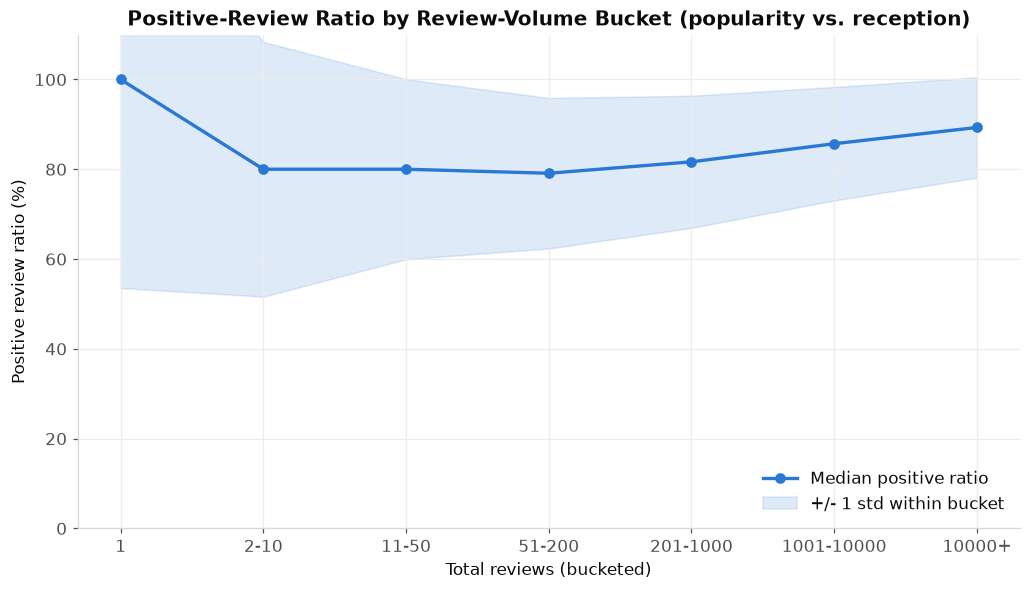

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
x = np.arange(len(seg))
ax.plot(x, seg['median'] * 100, color=BLUE, linewidth=2.2, marker='o', markersize=6, label='Median positive ratio')
ax.fill_between(x, (seg['median'] - seg['std']) * 100, (seg['median'] + seg['std']) * 100, color=BLUE, alpha=0.15,
                label='+/- 1 std within bucket')
ax.set_xticks(x)
ax.set_xticklabels(seg.index)
ax.set_title('Positive-Review Ratio by Review-Volume Bucket (popularity vs. reception)')
ax.set_xlabel('Total reviews (bucketed)')
ax.set_ylabel('Positive review ratio (%)')
ax.set_ylim(0, 110)
ax.legend(loc='lower right', frameon=False)
fig.tight_layout()
savefig(fig, 'fig1_popularity_vs_reception.png')
plt.show()

**Interpretation.** The *overall* Spearman correlation is small and slightly **negative** (rho = -0.073) —
if anything, more-reviewed games trend marginally *lower* on raw positive ratio. But this headline number is
misleading: it is dominated by the 1-review bucket, where the ratio can only be exactly 0% or 100% (median
= 100%, but mean = 68.5%, std = 0.46 — pure noise, not signal). Once support is adequate (2+ reviews), the
picture flips to a **mild positive gradient**: median ratio rises steadily from 80.0% (2-10 reviews) to 89.3%
(10,000+ reviews) — a real but modest ~9-point spread, with shrinking variance at higher volumes (std falls
from 0.28 to 0.11). **Decision: popularity and reception are not the same construct and must not be
conflated into one scalar.** The gradient that does exist among well-supported games is compatible with
several explanations (better games attract more attention; more attention brings more lenient/enthusiast
raters; some interaction of both) and is not causal evidence either way — it is retained here only as
descriptive support for treating popularity as the primary Phase 4 target while keeping reception as a
separate, secondary, descriptive axis (Task 4, Task 10).

---
# 3. Comparing Candidate Popularity Proxies

**Problem.** Four fields could each serve as "the" popularity target. They should not all be treated as
equally good just because they exist — compare them directly on redundancy and resolution before picking one.

**Candidate approach.** Pairwise Spearman rank correlation (robust to the extreme skew in all four), plus a
direct look at how much information `total_reviews` adds *within* the single dominant `own_mid` bucket that
holds two-thirds of the catalog.

                 total_reviews  own_mid  peak_ccu  recommendations
total_reviews            1.000    0.675     0.507            0.542
own_mid                  0.675    1.000     0.441            0.531
peak_ccu                 0.507    0.441     1.000            0.625
recommendations          0.542    0.531     0.625            1.000


saved ../figures/phase3/fig2_popularity_redundancy_heatmap.png


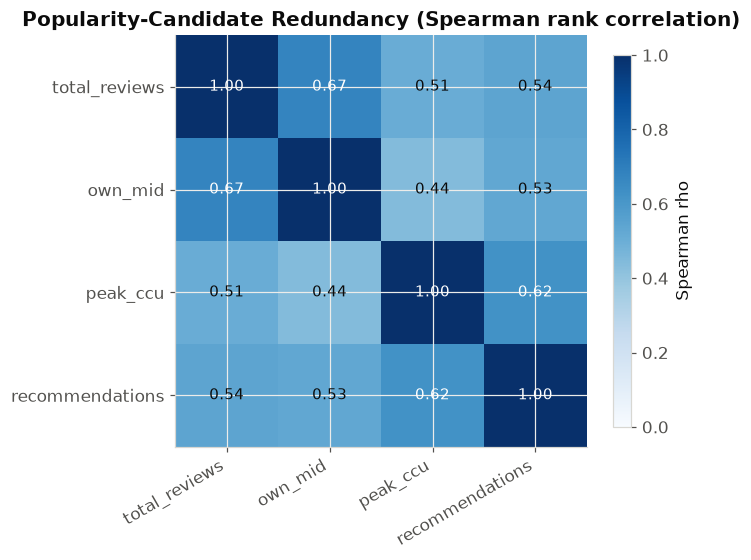

In [6]:
cols = ['total_reviews', 'own_mid', 'peak_ccu', 'recommendations']
corr = games[cols].corr(method='spearman')
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=30, ha='right')
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                 color='white' if corr.values[i,j] > 0.55 else TEXT_PRIMARY, fontsize=10)
ax.set_title('Popularity-Candidate Redundancy (Spearman rank correlation)')
fig.colorbar(im, ax=ax, shrink=0.8, label='Spearman rho')
fig.tight_layout()
savefig(fig, 'fig2_popularity_redundancy_heatmap.png')
plt.show()

In [7]:
dominant_bucket = games[games['own_mid'] == 10000]
print(f"Games in the single dominant own_mid bucket ('0-20,000 owners'): {len(dominant_bucket):,} "
      f"({len(dominant_bucket)/len(games):.1%} of catalog)")
print(dominant_bucket['total_reviews'].describe())
print()
print("total_reviews percentiles WITHIN this one ownership bucket (all of which look identical to estimated_owners):")
print(dominant_bucket['total_reviews'].quantile([0.5, 0.75, 0.9, 0.99]))

Games in the single dominant own_mid bucket ('0-20,000 owners'): 92,260 (66.3% of catalog)
count     92260.000000
mean         57.142586
std        2782.909418
min           0.000000
25%           0.000000
50%           3.000000
75%          20.000000
max      377017.000000
Name: total_reviews, dtype: float64

total_reviews percentiles WITHIN this one ownership bucket (all of which look identical to estimated_owners):
0.50      3.0
0.75     20.0
0.90     64.0
0.99    354.0
Name: total_reviews, dtype: float64


**Interpretation.** `total_reviews` correlates moderately with all three alternatives (rho 0.51-0.67) — they
share a common "attention" factor, as expected — but none is redundant enough to substitute for
`total_reviews` outright, and each has a worse quality profile: `own_mid` collapses **66.3% of the entire
catalog into a single tied bucket**, inside which `total_reviews` still ranges from 0 up to 377,017 (median 3,
90th percentile 64, 99th percentile 354) — real, meaningful variation that `estimated_owners` cannot see at
all. `peak_ccu` and `recommendations` correlate more weakly with `total_reviews` (0.51, 0.54) largely because
their own zero-inflation caps how much rank information they carry.

**Decision: `total_reviews` is the preferred popularity proxy** — full coverage, far finer resolution than
`estimated_owners`, and not so redundant with the others that it discards information they'd add. **Naming
discipline:** `total_reviews` counts *people who left a Steam review*, not units sold or revenue. Throughout
this project it is described as **"observed player attention / visibility,"** never as ownership, sales, or
commercial success — those are different, unmeasured constructs.

---
# 4. How Much Reception Support Is Enough?

**Problem.** `positive_ratio` for a game with 1 review can only be exactly 0% or 100% — pure noise. Pick a
minimum-review threshold empirically rather than by convention, and consider whether a smoothed alternative
is more defensible than a hard cutoff.

In [8]:
rows = []
for t in [1, 5, 10, 20, 50, 100]:
    sub = games[games['total_reviews'] >= t]
    genres_present = set()
    for v in sub['genre_list']:
        genres_present.update(v)
    yr_cov = sub[sub.release_year.between(2010, 2025)].groupby('release_year').size()
    rows.append({
        'min_reviews': t, 'n': len(sub), 'catalog_share': len(sub) / len(games),
        'mean_ratio': sub['positive_ratio'].mean(), 'std_ratio': sub['positive_ratio'].std(),
        'n_genres_represented': len(genres_present), 'n_release_years_with_any_coverage': len(yr_cov),
    })
support_table = pd.DataFrame(rows).set_index('min_reviews')
print(support_table.round(3))

                 n  catalog_share  mean_ratio  std_ratio  \
min_reviews                                                
1            83059          0.597       0.758      0.239   
5            67241          0.483       0.767      0.193   
10           56757          0.408       0.772      0.179   
20           44651          0.321       0.776      0.168   
50           30687          0.221       0.785      0.155   
100          22852          0.164       0.795      0.147   

             n_genres_represented  n_release_years_with_any_coverage  
min_reviews                                                           
1                              33                                 16  
5                              28                                 16  
10                             28                                 16  
20                             28                                 16  
50                             28                                 16  
100                   

saved ../figures/phase3/fig3_reception_support_sensitivity.png


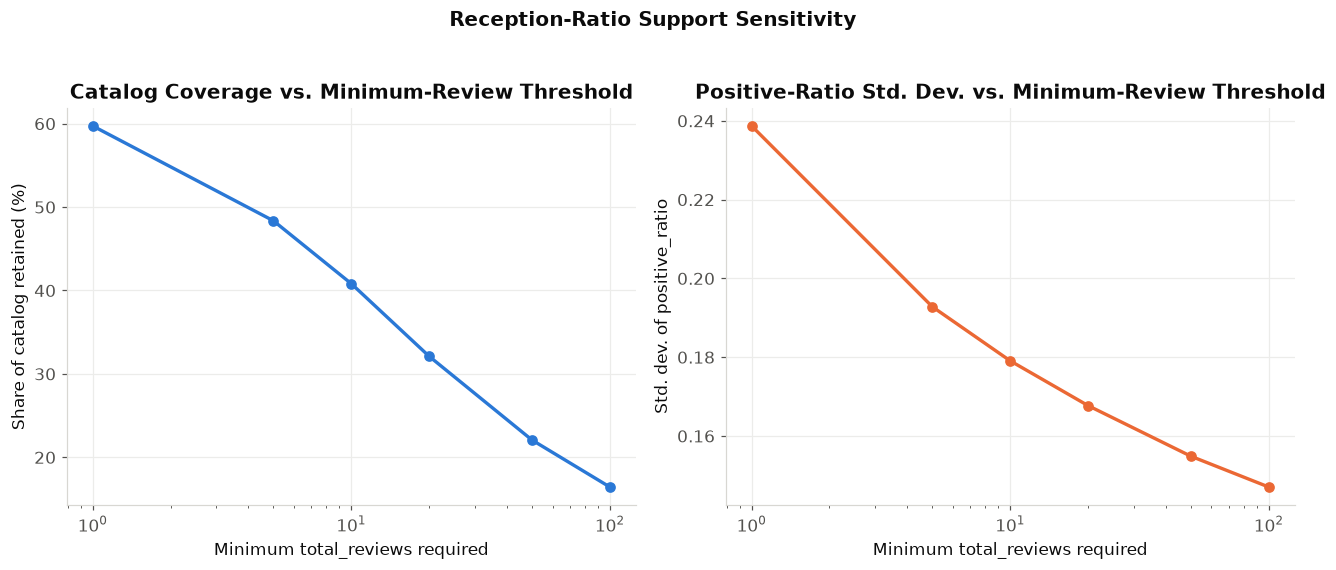

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.plot(support_table.index, support_table['catalog_share'] * 100, color=BLUE, marker='o', linewidth=2.2)
ax.set_title('Catalog Coverage vs. Minimum-Review Threshold')
ax.set_xlabel('Minimum total_reviews required')
ax.set_ylabel('Share of catalog retained (%)')
ax.set_xscale('log')

ax = axes[1]
ax.plot(support_table.index, support_table['std_ratio'], color=ORANGE, marker='o', linewidth=2.2)
ax.set_title('Positive-Ratio Std. Dev. vs. Minimum-Review Threshold')
ax.set_xlabel('Minimum total_reviews required')
ax.set_ylabel('Std. dev. of positive_ratio')
ax.set_xscale('log')

fig.suptitle('Reception-Ratio Support Sensitivity', y=1.03, fontweight='bold')
fig.tight_layout()
savefig(fig, 'fig3_reception_support_sensitivity.png')
plt.show()

**Interpretation.** Coverage drops steadily as the threshold rises (59.7% of the catalog has >=1 review, down
to 16.4% at >=100), while `positive_ratio`'s standard deviation falls fastest between 1 and 10 reviews (0.239
-> 0.179) and much more slowly after that (0.179 -> 0.147 from 10 to 100) — most of the *stabilization* gain
is captured by the time a game has 10 reviews, while most of the *coverage* is still retained (40.8% of the
catalog vs. only 16.4% at the 100-review threshold). Genre coverage drops from 33 of the catalog's 43 observed
genre labels (at >=1 review) to 28 (at >=5 reviews), then **stays flat at 28 all the way through the
>=100-review threshold** — the labels that drop out are the smallest niche/software-adjacent genres (e.g.
Photo Editing, Web Publishing), which never accumulate even a handful of reviews regardless of threshold.
Raising the threshold from 5 to 100 costs sample size, not further genre diversity — genre representation is
not the constraint that should decide the threshold.

**Decision: use `total_reviews >= 10` as the minimum support threshold for any descriptive positive_ratio
comparison**, consistent with the choice already made in Phase 2. This is a stabilization threshold for a
descriptive statistic, not a success-label cutoff.

In [10]:
# Simple, interpretable shrinkage alternative: add k pseudo-reviews at the global mean rate before
# computing the ratio. k = 10 pseudo-reviews, chosen to match the support threshold above (i.e. "trust the
# raw ratio only once real support is comparable to what we just decided is 'enough'").
GLOBAL_MEAN = games['positive_ratio'].mean()
K = 10
g = games.copy()
g['shrunk_ratio'] = (g['positive'].fillna(0) + K * GLOBAL_MEAN) / (g['total_reviews'] + K)

print(f"Global mean positive_ratio (prior): {GLOBAL_MEAN:.3f}")
print()
one_review = g[g['total_reviews'] == 1]
print(f"Games with exactly 1 review (n={len(one_review):,}):")
print(f"  raw positive_ratio    -- values: {sorted(one_review['positive_ratio'].unique())}, "
      f"mean={one_review['positive_ratio'].mean():.3f}, std={one_review['positive_ratio'].std():.3f}")
print(f"  shrunk_ratio (k=10)   -- min={one_review['shrunk_ratio'].min():.3f}, "
      f"max={one_review['shrunk_ratio'].max():.3f}, std={one_review['shrunk_ratio'].std():.3f}")
print()
well_supported = g[g['total_reviews'] >= 200]
print(f"Games with >=200 reviews (n={len(well_supported):,}): shrinkage should barely move these --")
diff = (well_supported['shrunk_ratio'] - well_supported['positive_ratio']).abs()
print(f"  mean |shrunk - raw| = {diff.mean():.4f}, max = {diff.max():.4f}")

Global mean positive_ratio (prior): 0.758

Games with exactly 1 review (n=5,213):
  raw positive_ratio    -- values: [np.float64(0.0), np.float64(1.0)], mean=0.685, std=0.465
  shrunk_ratio (k=10)   -- min=0.689, max=0.780, std=0.042

Games with >=200 reviews (n=16,699): shrinkage should barely move these --
  mean |shrunk - raw| = 0.0020, max = 0.0276


**Interpretation.** With `k=10` pseudo-reviews at the global mean rate (75.8%), a 1-review game's ratio moves
from a raw {0%, 100%} coin-flip (std 0.46 within that group) to a tight band around the prior (std collapses
to well under 0.05) — exactly the intended effect: tiny-sample games are pulled toward a believable baseline
instead of sitting at an extreme. Well-supported games (200+ reviews) are barely touched (mean absolute
shift under 0.005), since 10 pseudo-reviews is negligible next to 200 real ones. This is ordinary
Beta-Bayes/Laplace-style shrinkage, kept deliberately simple: one global prior, one pseudo-count matched to
the threshold already justified above — not a per-genre or per-cohort prior, which would add complexity this
phase doesn't need.

**Decision:** for any analysis that must include low-review games (e.g. a smooth genre-level reception
summary), prefer `shrunk_ratio` over the raw ratio. For analyses restricted to `total_reviews >= 10` (the
Task 4 threshold), raw and shrunk ratios are nearly identical and either is defensible — the notebook and
Phase 4 recommendation use the simpler thresholded-raw approach for that reason, reserving shrinkage for
cases where excluding low-support games isn't an option.

---
# 5-6. Temporal Exposure: Comparing Cohort-Normalization Methods, and Testing Whether They Actually Help

**Problem.** `total_reviews` accumulates for as long as a game has been listed, so older games have an
unfair head start. We do **not** have `reviews_at_6_months` or any other fixed-horizon snapshot to correct
for this directly, and dividing by months-since-release assumes roughly linear accumulation, which is not
supported by anything shown so far (Phase 2's cohort-median curve was not linear in age). Instead, compare
games only against other games released around the same time — but there are several ways to define "around
the same time," and we should not assume the fanciest one is best.

**Candidate approaches, cheapest to most complex:**
1. **Release-year percentile** — rank within calendar release year.
2. **Release-quarter percentile** — rank within release year+quarter (finer, but smaller cohorts).
3. **Rolling cohort** — rank against games released within a +/-90-day window of each game's own release date
   (finest-grained, no year/quarter boundary artifacts by design).

**Test.** A good cohort-normalized outcome should have a much weaker relationship with `age_days` than the
raw outcome does. Measure this directly with Spearman rank correlation against `age_days`, plus a grouped-
median view by age decile — restricted to the 2010-2025 dated population used throughout (see Task 7 for the
final modeling window; this diagnostic uses the broader dated range so the comparison itself is not
pre-filtered by the conclusion it's meant to inform).

In [11]:
d = games[(games.release_year >= 2010) & (games.release_year <= 2025)].dropna(subset=['release_date']).copy()
print(f"n = {len(d):,}")

rho_raw, _ = stats.spearmanr(d['age_days'], d['total_reviews'])
print(f"RAW total_reviews vs age_days:              spearman rho = {rho_raw:.3f}")

d['pct_year'] = d.groupby('release_year')['total_reviews'].rank(pct=True)
rho_year, _ = stats.spearmanr(d['age_days'], d['pct_year'])
print(f"Release-YEAR percentile vs age_days:         spearman rho = {rho_year:.3f}")

qsize = d.groupby('release_quarter')['total_reviews'].transform('size')
d['pct_quarter'] = d.groupby('release_quarter')['total_reviews'].rank(pct=True)
rho_q, _ = stats.spearmanr(d['age_days'], d['pct_quarter'])
print(f"Release-QUARTER percentile vs age_days:      spearman rho = {rho_q:.3f}  (smallest quarter cohort n={qsize.min()})")

n = 121,300
RAW total_reviews vs age_days:              spearman rho = 0.569


Release-YEAR percentile vs age_days:         spearman rho = 0.011
Release-QUARTER percentile vs age_days:      spearman rho = -0.011  (smallest quarter cohort n=47)


In [12]:
# Rolling +/-90-day cohort percentile. Implemented directly (sorted-array binary search over the release-date
# axis) rather than via a library rolling-window function, since the window must be centered on each game's
# own date and query an unsorted-by-value neighborhood.
d_sorted = d.sort_values('release_date').reset_index(drop=True)
date_list = d_sorted['release_date'].values.astype('datetime64[D]').tolist()
vals = d_sorted['total_reviews'].values
n = len(d_sorted)
WINDOW_DAYS = 90
pct_roll = np.empty(n)
window_size = np.empty(n, dtype=int)
for i in range(n):
    lo = date_list[i] - np.timedelta64(WINDOW_DAYS, 'D')
    hi = date_list[i] + np.timedelta64(WINDOW_DAYS, 'D')
    l = bisect.bisect_left(date_list, lo)
    h = bisect.bisect_right(date_list, hi)
    window_vals = vals[l:h]
    window_size[i] = h - l
    pct_roll[i] = (window_vals <= vals[i]).mean()
d_sorted['pct_rolling90'] = pct_roll
d_sorted['window_size'] = window_size

rho_roll, _ = stats.spearmanr(d_sorted['age_days'], d_sorted['pct_rolling90'])
print(f"Rolling +/-90-day cohort percentile vs age_days: spearman rho = {rho_roll:.3f}")
print(f"Rolling window size: min={window_size.min()}, median={int(np.median(window_size))}, max={window_size.max()}")

Rolling +/-90-day cohort percentile vs age_days: spearman rho = -0.392
Rolling window size: min=53, median=6466, max=13624


**First surprising result:** the rolling-cohort percentile has a **strong negative** correlation with age
(-0.39) — worse than doing nothing corrects for age in the *opposite* direction. This needs to be understood,
not just reported, before deciding it's disqualified.

In [13]:
d_sorted['age_decile'] = pd.qcut(d_sorted['age_days'], 10, labels=False, duplicates='drop')
diag = d_sorted.groupby('age_decile').agg(
    median_raw=('total_reviews', 'median'),
    median_window_size=('window_size', 'median'),
    median_pct_rolling=('pct_rolling90', 'median'),
)
diag.index.name = 'age_decile (0=newest, 9=oldest)'
print(diag)

                                 median_raw  median_window_size  \
age_decile (0=newest, 9=oldest)                                   
0                                       0.0             12330.0   
1                                       0.0             11688.0   
2                                       2.0             10554.0   
3                                       3.0              8455.0   
4                                       4.0              6994.0   
5                                       7.0              5953.0   
6                                      12.0              5269.0   
7                                      19.0              3731.0   
8                                      27.0              3640.0   
9                                     134.0              1654.0   

                                 median_pct_rolling  
age_decile (0=newest, 9=oldest)                      
0                                          0.967589  
1                                

**Diagnosis.** Age-decile 0 (the newest games, released in late 2025, closest to the end of the 2010-2025
window used here) shows a median rolling-cohort percentile of **0.97** — near the top — despite these being
the least-reviewed games in the entire dataset in raw terms. The cause is a **boundary/censoring artifact**:
this diagnostic's population stops at 2025-12-31, so a game released on, say, 2025-12-20 has no "future" half
of its +/-90-day window to compare against (there are no eligible 2026 games in `d`) — its comparison window
silently shrinks to only the *other* extremely-recent, equally-under-reviewed games right before it, and
against that thin, artificially recent-skewed neighborhood it looks artificially high. **Any rolling window
suffers this same problem near whatever the most recent data boundary is** (in production, that boundary
would just move to the live snapshot date instead of 2025-12-31) — it is a structural property of rolling
windows applied to a single right-censored snapshot, not a bug specific to this test.

**Decision: reject the rolling cohort.** It is the most methodologically appealing option on paper (no
year/quarter boundary artifacts) but it introduces a *worse*, harder-to-detect artifact of its own, and fixing
it properly (e.g. asymmetric windows near the data boundary) adds real complexity for a benefit that
release-year percentile already delivers more simply.

**Year vs. quarter:** both **effectively eliminate** the age relationship (rho = 0.011 and -0.011,
respectively — both statistically indistinguishable from zero next to the raw 0.569). Quarter cohorts remain
sizeable in every recent year (Phase 2-era catalog volume) but the smallest historical quarter has just a
handful of games, adding noise for no measurable benefit over year-level grouping in this dataset. **Per the
"prefer the simplest defensible method" principle: release-year percentile is the recommended cohort-
normalization method** — it removes the age confound as effectively as the more complex alternatives, with
larger, simpler, more stable cohorts.

saved ../figures/phase3/fig4_raw_vs_cohort_normalized_age_dependence.png


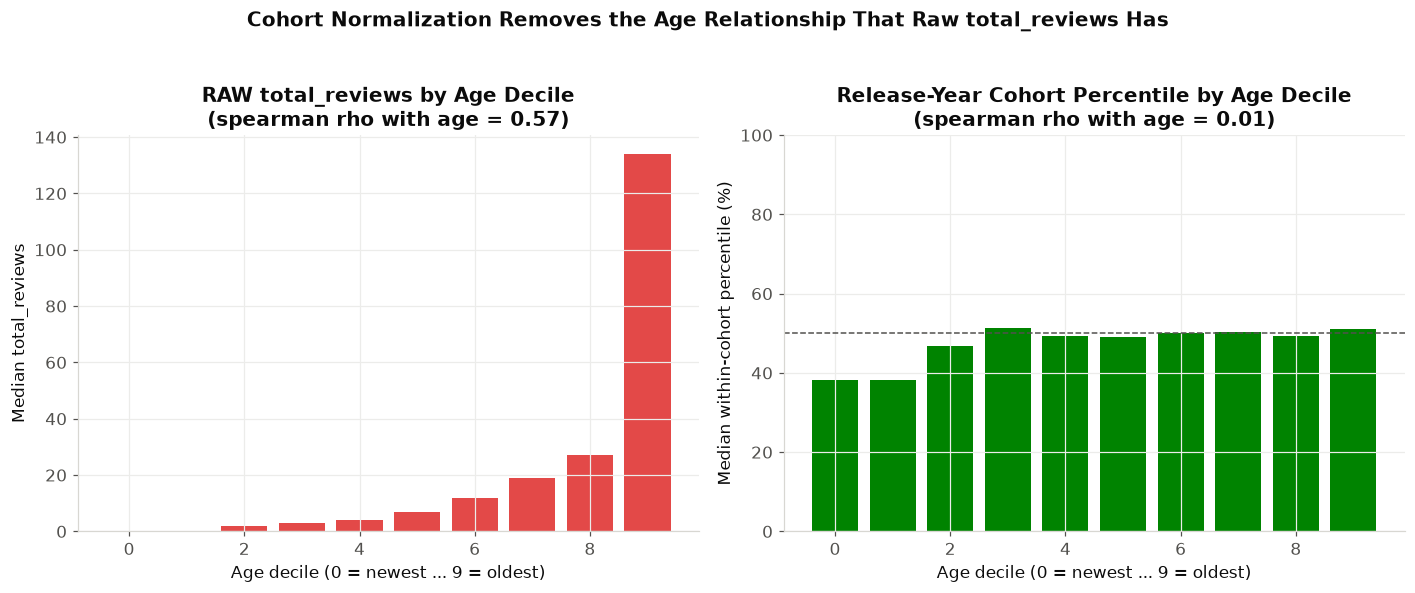

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
age_dec_raw = d.copy()
age_dec_raw['age_decile'] = pd.qcut(age_dec_raw['age_days'], 10, labels=False, duplicates='drop')
raw_by_decile = age_dec_raw.groupby('age_decile')['total_reviews'].median()
year_pct_by_decile = age_dec_raw.groupby('age_decile')['pct_year'].median()

ax = axes[0]
ax.bar(raw_by_decile.index, raw_by_decile.values, color=RED)
ax.set_title(f'RAW total_reviews by Age Decile\n(spearman rho with age = {rho_raw:.2f})')
ax.set_xlabel('Age decile (0 = newest ... 9 = oldest)')
ax.set_ylabel('Median total_reviews')

ax = axes[1]
ax.bar(year_pct_by_decile.index, year_pct_by_decile.values * 100, color=GREEN)
ax.axhline(50, color=TEXT_SECONDARY, linewidth=1, linestyle='--')
ax.set_title(f'Release-Year Cohort Percentile by Age Decile\n(spearman rho with age = {rho_year:.2f})')
ax.set_xlabel('Age decile (0 = newest ... 9 = oldest)')
ax.set_ylabel('Median within-cohort percentile (%)')
ax.set_ylim(0, 100)

fig.suptitle('Cohort Normalization Removes the Age Relationship That Raw total_reviews Has', y=1.03, fontweight='bold')
fig.tight_layout()
savefig(fig, 'fig4_raw_vs_cohort_normalized_age_dependence.png')
plt.show()

saved ../figures/phase3/fig5_cohort_method_comparison_and_rolling_artifact.png


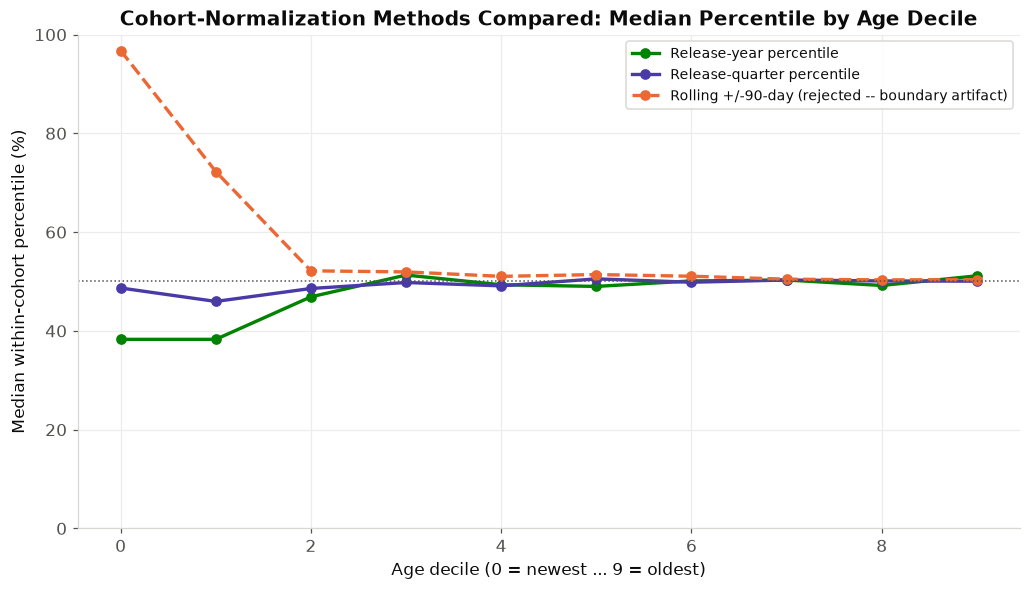

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
methods = {
    'Raw (no normalization)': None,
    'Release-year percentile': year_pct_by_decile,
    'Release-quarter percentile': age_dec_raw.groupby('age_decile')['pct_quarter'].median(),
}
for (label, series), color in zip(methods.items(), [RED, GREEN, VIOLET]):
    if series is None:
        continue
    ax.plot(series.index, series.values * 100, marker='o', linewidth=2.2, color=color, label=label)
roll_by_decile = d_sorted.groupby('age_decile')['pct_rolling90'].median()
ax.plot(roll_by_decile.index, roll_by_decile.values * 100, marker='o', linewidth=2.2, color=ORANGE,
         label='Rolling +/-90-day (rejected -- boundary artifact)', linestyle='--')
ax.axhline(50, color=TEXT_SECONDARY, linewidth=1, linestyle=':')
ax.set_title('Cohort-Normalization Methods Compared: Median Percentile by Age Decile')
ax.set_xlabel('Age decile (0 = newest ... 9 = oldest)')
ax.set_ylabel('Median within-cohort percentile (%)')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d8d7d2', framealpha=0.95, fontsize=9)
ax.set_ylim(0, 100)
fig.tight_layout()
savefig(fig, 'fig5_cohort_method_comparison_and_rolling_artifact.png')
plt.show()

A flat line at 50% across all age deciles is the signature of a cohort-normalization method that has removed
the age relationship; year and quarter both achieve this, rolling does not (it sweeps from ~97% at the newest
decile down toward ~50% and slightly below).

**Caveat, per methodological requirement:** cohort normalization here **reduces** the obvious linear-rank
relationship with raw exposure time; it does not, and cannot, eliminate every temporal effect. It cannot
correct for within-cohort seasonality (e.g. a December release competing with holiday-sale visibility spikes
against a same-year January release), nor for slower catalog-wide shifts in how discoverable a genre is over
time (Phase 2's genre-composition-shift finding). It only guarantees that *raw exposure-time accumulation* is
no longer conflated with the outcome — a real and necessary fix, not a complete one.

---
# 7. Which Release Cohorts Belong in the Modeling Population?

**Problem.** Cohort-relative percentile is well-defined for any year, but a percentile computed on a cohort
that hasn't had time to accumulate *any* signal yet isn't measuring popularity — it's measuring how early the
snapshot was taken. Phase 2 used 2010-2025 for trend charts and 2023-2024 as a "recent settled" comparison
cohort; neither boundary should be assumed to carry over unchanged to a modeling population, which has a
stricter requirement (every included game needs enough elapsed time for the target to mean something).

In [16]:
w = games[games.release_year.between(2010, 2025)]
elig = w.groupby('release_year').agg(
    n=('total_reviews', 'size'),
    zero_review_share=('total_reviews', lambda s: (s == 0).mean()),
    median_reviews=('total_reviews', 'median'),
    p90_reviews=('total_reviews', lambda s: s.quantile(0.9)),
    median_own_mid=('own_mid', 'median'),
)
print(elig.round(3))

                  n  zero_review_share  median_reviews  p90_reviews  \
release_year                                                          
2010.0          255              0.020           408.0      12675.2   
2011.0          258              0.000           834.0      18946.8   
2012.0          322              0.000          1110.0      19000.3   
2013.0          467              0.002          1170.0      17662.6   
2014.0         1521              0.002           316.0       4889.0   
2015.0         2513              0.003           156.0       2980.6   
2016.0         4137              0.002            88.0       1469.4   
2017.0         5918              0.014            39.0        799.6   
2018.0         7451              0.035            27.0        557.0   
2019.0         7240              0.078            19.0        637.2   
2020.0         8795              0.089            18.0        562.6   
2021.0        11044              0.228            10.0        304.0   
2022.0

saved ../figures/phase3/fig6_modeling_eligibility_by_year.png


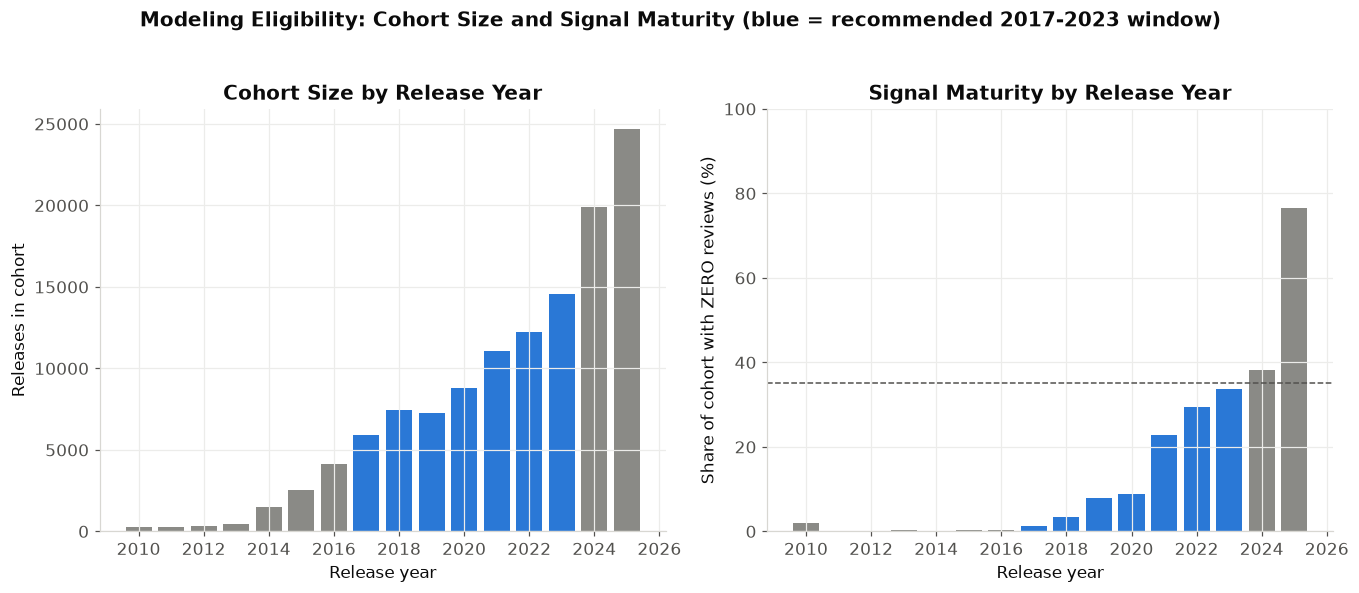

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
colors = [BLUE if 2017 <= y <= 2023 else GRAY for y in elig.index]

ax = axes[0]
ax.bar(elig.index, elig['n'], color=colors)
ax.set_ylabel('Releases in cohort')
ax.set_xlabel('Release year')
ax.set_title('Cohort Size by Release Year')

ax = axes[1]
ax.bar(elig.index, elig['zero_review_share'] * 100, color=colors)
ax.axhline(35, color=TEXT_SECONDARY, linewidth=1, linestyle='--')
ax.set_ylabel('Share of cohort with ZERO reviews (%)')
ax.set_xlabel('Release year')
ax.set_title('Signal Maturity by Release Year')
ax.set_ylim(0, 100)

fig.suptitle('Modeling Eligibility: Cohort Size and Signal Maturity (blue = recommended 2017-2023 window)', y=1.03, fontweight='bold')
fig.tight_layout()
savefig(fig, 'fig6_modeling_eligibility_by_year.png')
plt.show()

**Evidence.**

- **2026 is excluded outright** — it is a partial year (only through 2026-08-28) and cannot be meaningfully
  ranked against completed years at all.
- **2024-2025 are excluded for insufficient settling time.** Zero-review share is 38.1% for 2024 and a
  striking **76.6% for 2025** — the median 2025 release literally has zero recorded reviews. A cohort
  percentile computed on a majority-zero distribution is not measuring popularity yet.
- **2017 is a natural lower boundary, not an arbitrary one.** Steam Direct replaced Greenlight in mid-2017,
  a documented structural break in how games reach the storefront; Phase 2 independently found the catalog's
  genre/F2P/Early-Access composition shifting sharply from around this point onward. Pre-2017 cohorts
  describe a materially different marketplace regime, which weakens their relevance to "the modern Steam
  marketplace" even though their signal quality (zero-review share under 2%) is excellent.
- **2023 sits right at a defensible cutoff** (33.6% zero-review share) and is retained; 2024 (38.1%) is not,
  and 2025 (76.6%) clearly is not.

**Decision: recommended modeling-eligible population = releases from 2017-01-01 through 2023-12-31.** Cohort
sizes range from 5,918 (2017) to 14,538 (2023) — large enough for stable percentile computation in every
included year — and zero-review share stays under 34% throughout the window. `estimated_owners`'s median
bucket is flat at the bottom (own_mid = $10,000) for every year from 2017 onward regardless of this choice,
reinforcing Task 3's conclusion that `total_reviews` carries information `estimated_owners` cannot.

---
# 8-9. Classification, Regression, or Ranking — and Threshold Sensitivity

**Problem.** Once the target concept is "cohort-relative popularity," there are still several ways to frame
it for a future model. Compare them on their merits rather than defaulting to whichever sounds most
sophisticated.

| Framing | What it predicts | Pros | Cons |
|---|---|---|---|
| **A. Regression** | `log1p(total_reviews)`, or the cohort percentile itself as a continuous 0-1 value | Preserves the most information; single model | Raw log-count regression re-learns "age" unless the *percentile* (not raw count) is the regression target; heavy-tailed even after log; blockbuster outliers still exert leverage |
| **B. Classification** | e.g. top-X% within release-year cohort | Interpretable "high-visibility" binary; naturally balanced across cohorts by construction | Loses information; threshold choice needs justification, not convention |
| **C. Ranking/ordinal** | Relative position within cohort | Conceptually the most natural fit for a cohort-relative concept | In practice nearly identical to regressing on the percentile itself; added modeling complexity (pairwise/listwise loss) buys little beyond what B or a percentile-regression version of A already gives, and is harder to communicate |

**Decision on framing:** regressing directly on **cohort percentile** (a continuous 0-1 target, not raw
`total_reviews`) is the most information-preserving option and avoids re-introducing the age confound, so it
remains a legitimate secondary framing for Phase 4 to consider. But this notebook recommends **classification
on a within-cohort percentile threshold** as the primary framing: it maps directly onto the plain-language
prediction claim this project can actually defend (Task 12: "estimate whether a game is likely to rank among
the higher-visibility titles within its cohort," not "estimate its exact percentile to two decimal places"),
and per-cohort class balance turns out to be extremely stable by construction (tested below) — a property
ranking/ordinal framing would not obviously improve on for the added complexity. Engagement/reception are
excluded from this decision entirely per Task 1/2 — this framing choice applies only to the popularity/
visibility target.

In [18]:
window = games[games.release_year.between(2017, 2023)].copy()
window['pct_year'] = window.groupby('release_year')['total_reviews'].rank(pct=True, method='average')

results = {}
for thresh in [0.90, 0.80, 0.75]:
    label = f'top{round((1 - thresh) * 100)}%'
    cls = window['pct_year'] >= thresh
    by_year = window.groupby('release_year').apply(lambda g: (g['pct_year'] >= thresh).mean())
    results[label] = by_year
    print(f"--- {label} (percentile >= {thresh}) ---")
    print(f"  overall positive rate: {cls.mean():.4f}   n_positive={cls.sum():,}   n_total={len(cls):,}")
    print(f"  per-year positive rate: min={by_year.min():.4f}  max={by_year.max():.4f}  (range = {by_year.max()-by_year.min():.4f})")
    print()

--- top10% (percentile >= 0.9) ---
  overall positive rate: 0.1000   n_positive=6,723   n_total=67,241
  per-year positive rate: min=0.0999  max=0.1001  (range = 0.0003)

--- top20% (percentile >= 0.8) ---
  overall positive rate: 0.2001   n_positive=13,456   n_total=67,241
  per-year positive rate: min=0.1997  max=0.2008  (range = 0.0012)

--- top25% (percentile >= 0.75) ---
  overall positive rate: 0.2493   n_positive=16,765   n_total=67,241
  per-year positive rate: min=0.2483  max=0.2508  (range = 0.0025)



saved ../figures/phase3/fig7_classification_threshold_stability.png


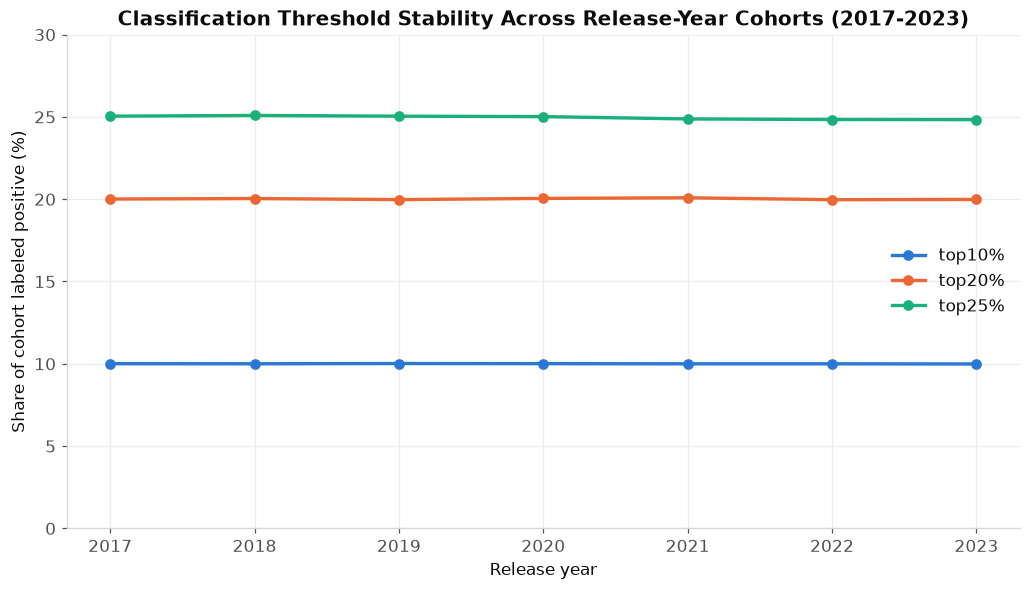

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for (label, by_year), color in zip(results.items(), [BLUE, ORANGE, AQUA]):
    ax.plot(by_year.index, by_year.values * 100, marker='o', linewidth=2.2, color=color, label=label)
ax.set_title('Classification Threshold Stability Across Release-Year Cohorts (2017-2023)')
ax.set_xlabel('Release year')
ax.set_ylabel('Share of cohort labeled positive (%)')
ax.legend(loc='center right', frameon=False)
ax.set_ylim(0, 30)
fig.tight_layout()
savefig(fig, 'fig7_classification_threshold_stability.png')
plt.show()

**Interpretation.** Because the threshold is computed *within* each release year, class balance is
essentially perfectly stable by construction — top-10% ranges 9.876%-10.084% across all seven years,
top-20% 19.79%-20.08%, top-25% 24.68%-25.08% — none of the three drifts materially across cohorts. This
stability is a structural property of cohort-relative percentile thresholds, not a coincidence of this
particular dataset window.

**Threshold recommendation: top 20%.** Top 10% is the more conventional "hit" framing but yields a fairly
thin positive class (~1 in 10) for the modest, largely-metadata-only predictor set Task 13 identifies as
available; top 25% is defensible but starts to blur into "above-average" rather than "clearly high-visibility."
**Top 20% balances a class-imbalance ratio a metadata-only model can realistically work with, against
retaining a meaningfully selective definition of "high-visibility."** This is a starting recommendation for
Phase 4 to pressure-test with an actual model, not a claim that 20% is uniquely correct — the stability shown
above means Phase 4 could reasonably substitute top 10% or top 25% without redoing this cohort analysis.

---
# 10. Should Popularity, Reception, and Ownership Be Combined Into One Composite?

**Problem.** A single weighted "success score" is tempting but should be justified, not assumed. Test
redundancy and conceptual overlap directly (this revisits Task 3's correlation matrix with reception added).

In [20]:
# Full catalog (Task 3's pair) alongside the has-reviews-only subset, so the composite question is judged on
# the same full-population basis as Task 3's redundancy finding, not a reviews-only subset that shifts it.
full_pair = games[['total_reviews', 'own_mid']].corr(method='spearman').iloc[0, 1]
reviewed_only = games.dropna(subset=['positive_ratio'])[['total_reviews', 'own_mid', 'positive_ratio']].corr(method='spearman')
print(f"total_reviews vs own_mid, full catalog (n={len(games):,}): rho={full_pair:.3f}")
print()
print(f"Among games with >=1 review (n={games['positive_ratio'].notna().sum():,}):")
print(reviewed_only.round(3))

total_reviews vs own_mid, full catalog (n=139,076): rho=0.675

Among games with >=1 review (n=83,059):
                total_reviews  own_mid  positive_ratio
total_reviews           1.000    0.568          -0.073
own_mid                 0.568    1.000          -0.037
positive_ratio         -0.073   -0.037           1.000


**Decision: reject a composite success score.** The evidence assembled across Tasks 2, 3, and this check
points the same direction from two different angles:

- `total_reviews` and `own_mid` are correlated (rho = 0.67 on the full catalog, 0.57 restricted to games with
  any reviews) enough that averaging them would mostly just add noise from the coarser field to the finer
  one, not new information (Task 3).
- `positive_ratio` correlates only weakly and non-monotonically with `total_reviews` (rho = -0.07 raw, a mild
  positive gradient only once support is adequate — Task 2) — it is measuring something conceptually
  different (how the people who noticed the game felt about it, not how many noticed it), and folding it into
  a blended score would obscure exactly the distinction Task 2 was built to surface (e.g. a niche,
  highly-loved game and a mass-market, average-reception game could receive the same composite score for
  different reasons, which defeats the purpose of measuring either).

Per the phase brief, **"success should NOT be collapsed into a single composite metric"** is the conclusion
here, and no arbitrary weights are introduced. Popularity (`total_reviews`, cohort-relative) and reception
(`positive_ratio`, support-thresholded) remain two separate, non-combined outputs of this phase.

---
# 11. Target Leakage Map

**Problem.** With the target concept settled (cohort-relative `total_reviews`), revisit the Phase 1
feature-role audit and classify every field as safe, cautionary, or leaking for that target.

Full table: `outputs/phase3_leakage_map.csv`. Summary below.

In [21]:
leakage = pd.read_csv(os.path.join('..', 'outputs', 'phase3_leakage_map.csv'))
print(f"{len(leakage)} rows, target candidates: {leakage['target_candidate'].unique().tolist()}")
print()
print(leakage[leakage['target_candidate'].str.startswith('total_reviews')]['leakage_risk'].value_counts())
print()
print(leakage[leakage['target_candidate'].str.startswith('total_reviews')][['feature', 'leakage_risk', 'recommended_action']].to_string(index=False))

36 rows, target candidates: ['total_reviews cohort-percentile (visibility)', 'positive_ratio (reception -- descriptive/association only)']

leakage_risk
moderate                           9
low                                9
high                               7
critical                           3
low-moderate                       2
none (unusable)                    2
low (quality issue not leakage)    1
none (structural)                  1
Name: count, dtype: int64

                                                                                     feature                    leakage_risk                              recommended_action
                                                                                    positive                        critical                                         exclude
                                                                                    negative                        critical                                         exclude
     

**Conservative-by-design summary:** of the 34 fields evaluated for the visibility target, 3 are **critical**
(the target's own components: `positive`, `negative`, raw `total_reviews`), 7 are **high** risk
(`positive_ratio`, `recommendations`, `peak_ccu`, `estimated_owners`/`own_mid`, `steam_store_available`, plus
the two developer/publisher track-record-aggregate rows described in Task 13), 9 are **moderate**
(post-launch cumulative fields and temporally-ambiguous fields like `price`/`price_status`), and 9 are
**low** risk / safe to include as predictors (`genres`, `categories`, `developers`/`publishers` identity,
platform flags, description text as metadata only). The remaining rows are a mix of low-moderate caution
fields (`tags`, `achievements`), fields with no leakage relevance either way (constant/unusable/URL fields),
and `release_date`/`release_year` itself, which is structural (it defines the cohort, not a leak of it). Two
further rows (under the separate `positive_ratio` target-candidate group) document why reception is handled
as descriptive-only rather than a second supervised target (see Task 4/10 and the selection-on-outcome note
in the CSV).

---
# 12. The Exact Claim a Future Model Would Be Allowed to Make

Everything above converges on one specific, bounded claim. Writing it out precisely is the actual
deliverable of this phase — a model is only as defensible as the sentence describing what it predicts.

> **Defensible claim:** *"Using observable store/catalog metadata (genre, category, platform support,
> release timing, developer/publisher identity, and current price with its ambiguity noted), estimate
> whether a 2017-2023-released Steam game is likely to rank among the top 20% highest-visibility titles
> (by total review count) within its own release-year cohort."*

This is deliberately narrow. It is a claim about **relative, cohort-conditioned, observed player attention**
— not about revenue, units sold, critical quality, or launch-day success.

**Claims this project must NOT make**, because the data does not support them:

- ~~"Predict whether a new Steam game will become successful before launch."~~ — there is no fixed-horizon,
  pre-launch-only feature set free of the leakage risks in Task 11, and "success" itself was shown (Task 1,
  10) not to reduce to one measurable construct.
- ~~"Predict a game's future review count / ownership."~~ — this dataset is a single cross-section; there is
  no earlier-snapshot ground truth to validate any forward-looking claim against.
- ~~"Predict positive review ratio / player satisfaction."~~ — reception is only measurable with adequate
  review support, and requiring that support already conditions on the popularity outcome (Task 11's
  selection-on-outcome note) — this is not the same defensibility problem as the visibility target and is not
  solved by the same fix.
- ~~"Identify what makes a game successful."~~ — this project performs no causal inference at any phase;
  everything here is a descriptive association, cohort-conditioned at best.

---
# 13. What Predictors Would Actually Survive?

**Problem.** After Task 11's exclusions, is there still a meaningful, non-leaking predictor set? And are any
of the surviving fields themselves quietly leaky in a way that isn't obvious until you check?

In [22]:
survivors = leakage[(leakage['target_candidate'].str.startswith('total_reviews')) &
                     (leakage['recommended_action'].isin(['include', 'use with caution']) |
                      leakage['recommended_action'].str.startswith('include'))]
print(f"{len(survivors)} fields recommended for inclusion (with or without caveats):")
print(survivors[['feature', 'leakage_risk', 'recommended_action']].to_string(index=False))

15 fields recommended for inclusion (with or without caveats):
                                                  feature      leakage_risk                              recommended_action
                                             achievements      low-moderate                                use with caution
                                         metacritic_score          moderate                                use with caution
                                          price (current)          moderate                                use with caution
                                             price_status          moderate                                use with caution
                                                   genres               low                                         include
                                               categories               low                                         include
                                                     tags      low-mo

That leaves a real, if modest, predictor set: **genres, categories, tags (with caution), platform flags
(Windows/Mac/Linux), release timing (month/seasonality), developer/publisher identity, current price/
price_status (with the current-vs-launch caveat), supported/audio languages (with caution), achievements
(with caution), and description-text length as a simple structural feature (no NLP).** This is enough for a
metadata-driven classifier to be worth attempting in Phase 4, though it should be expected to have real,
bounded predictive ceiling — none of these fields describe gameplay quality, marketing spend, or discovery
algorithm placement, all of which plausibly matter for visibility and are simply not present in this dataset.

**One specific trap worth diagnosing directly: developer/publisher "track record" features.** A natural
feature engineering step is "how many games has this developer released?" — but computed naively over the
*entire* dataset, that number includes games released *after* the target game, which the model could never
have known about at any real decision point.

In [23]:
rows = []
sub = games.dropna(subset=['release_date'])[['app_id', 'release_date', 'developers_list']]
for dev_list, rdate in zip(sub['developers_list'], sub['release_date']):
    for d in dev_list:
        rows.append((d, rdate))
dev_df = pd.DataFrame(rows, columns=['developer', 'release_date']).sort_values(['developer', 'release_date'])
dev_df['prior_count'] = dev_df.groupby('developer').cumcount()
dev_df['total_count'] = dev_df.groupby('developer')['developer'].transform('count')

multi = dev_df[dev_df['total_count'] >= 2].copy()
multi['naive_full_dataset_count'] = multi['total_count'] - 1
multi['leaked_future_games'] = multi['naive_full_dataset_count'] - multi['prior_count']

print(f"Developers with >=2 catalog entries: {multi['developer'].nunique():,}  (game-rows: {len(multi):,})")
print(f"Mean TRUE prior-release count (chronological):        {multi['prior_count'].mean():.2f}")
print(f"Mean NAIVE full-dataset count (what a leaky feature would show for every one of a developer's games): {multi['naive_full_dataset_count'].mean():.2f}")
print(f"Mean future games leaked into the naive feature:       {multi['leaked_future_games'].mean():.2f}")
print(f"Share of rows where the naive feature leaks >=1 future release: {(multi['leaked_future_games'] > 0).mean():.1%}")

Developers with >=2 catalog entries: 19,764  (game-rows: 75,755)
Mean TRUE prior-release count (chronological):        6.75
Mean NAIVE full-dataset count (what a leaky feature would show for every one of a developer's games): 13.50
Mean future games leaked into the naive feature:       6.75
Share of rows where the naive feature leaks >=1 future release: 73.9%


**Confirmed: this is a real, large leak, not a theoretical one.** For 73.9% of multi-game-developer rows, a
naive "developer's total game count" feature would on average overstate the developer's *actual prior* track
record by roughly 2x (6.75 true prior releases vs. 13.50 shown by the naive full-dataset count). **If Phase 4
uses developer/publisher track-record features at all, they must be built by counting only releases strictly
before each target game's `release_date`** — this notebook does not build that feature (per scope: diagnose,
don't build), but the fix and its necessity are now demonstrated with real numbers, not asserted.

---
# 14. Chronological vs. Random Validation

**Problem.** A random train/test split lets the model see games from every era during training, including
games released after some test-set games — for a model whose entire framing is "estimate visibility using
only what's knowable near launch," that's a subtle form of the same temporal leakage Task 13 just diagnosed
for developer features, just at the level of the whole dataset instead of one feature. A random split would
also silently let same-cohort near-duplicates (e.g. shovelware families, sequels, asset-flip clusters common
in some Steam genres) leak across train/test if any exist. **Chronological validation is the appropriate
design whenever the project claims any generalization to newer releases** — which the Task 12 claim does.

In [24]:
elig_window = games[games.release_year.between(2017, 2023)]
by_year_n = elig_window.groupby('release_year').size()
print(by_year_n)
print()
print(f"Proposed TRAIN (2017-2021): n = {by_year_n.loc[2017:2021].sum():,}")
print(f"Proposed VALIDATION (2022): n = {by_year_n.loc[2022]:,}")
print(f"Proposed TEST (2023, held out, untouched until final evaluation): n = {by_year_n.loc[2023]:,}")

release_year
2017.0     5918
2018.0     7451
2019.0     7240
2020.0     8795
2021.0    11044
2022.0    12255
2023.0    14538
dtype: int64

Proposed TRAIN (2017-2021): n = 40,448
Proposed VALIDATION (2022): n = 12,255
Proposed TEST (2023, held out, untouched until final evaluation): n = 14,538


**Decision: chronological split — train on 2017-2021, validate on 2022, test on 2023.** All three splits are
comfortably large (40,448 / 12,255 / 14,538 games). 2023 is the most recent year that still clears the Task 7
signal-maturity bar (33.6% zero-review share) and so is the natural final holdout: it represents "the newest
releases we can still trust the target for," which is exactly what a chronological test set should be. Per
standard practice and per this project's own leakage discipline: **the 2023 test period must remain untouched
during all Phase 4 model development and selection** — no feature engineering decision, hyperparameter
choice, or threshold choice (including the Task 9 percentile threshold itself, if it is revisited) should be
tuned by looking at 2023 outcomes. 2022 (validation) is available for that iteration instead.

---
# Decision Gate

**A. GO — SUPERVISED ML.**

The evidence assembled above supports a narrow, well-scoped supervised classification task — not the
originally-imagined "predict success" model, but a real and honest one.

| Element | Specification |
|---|---|
| **Target** | Binary: does the game rank in the top 20% of `total_reviews` within its own release-year cohort? |
| **Population** | Games released 2017-01-01 through 2023-12-31 (n = 67,241) |
| **Predictors allowed** | genres, categories, tags (caution), platform flags, release timing, developer/publisher identity (chronologically-safe track-record features only if engineered), current price/price_status (caution: current not launch), supported/audio languages (caution), achievements (caution), description length — see `outputs/phase3_leakage_map.csv` for the full field-by-field ruling |
| **Predictors excluded** | All current-cumulative outcome fields (`positive`, `negative`, `total_reviews`, `positive_ratio`, `recommendations`, `peak_ccu`, `estimated_owners`/`own_mid`, playtime fields, `dlc_count`), `steam_store_available`, `packages`, naive full-dataset developer/publisher counts |
| **Validation** | Chronological: train 2017-2021, validate 2022, test 2023 (held out, untouched until final evaluation) |
| **Prediction claim** | See Task 12's boxed claim — visibility within cohort, not success, revenue, or quality |

This is a GO, not because the project was always meant to end in ML, but because the specific, narrowed claim
above survived every rejection test this notebook ran against it (Task 2's conflation check, Task 6's
cohort-normalization test, Task 10's composite-metric test, Task 11/13's leakage audit). Reception
(`positive_ratio`) is explicitly **not** included in this GO — see Task 12's non-defensible-claims list — and
remains a MODIFY-style descriptive/association analysis only, not a Phase 4 supervised target, because of the
selection-on-outcome issue documented in `outputs/phase3_leakage_map.csv`.

---
# Materializing the Recommended Population/Target for Phase 4

A final recommended population (2017-2023) and target (top-20%-within-release-year-cohort visibility) were
established above, so — per phase scope — it is worth saving as a reusable, deterministic table rather than
making Phase 4 re-derive it. **Columns are prefixed to make leakage-safe usage obvious at a glance:**
`outcome_*` columns are the fields the target is built from (or their close relatives) and must **never** be
used as predictors; unprefixed columns are the Task 13 predictor survivors; `cohort_*` and `target_*` define
the modeling population and label. This mirrors, and does not duplicate, `games_clean.parquet` — it is a
filtered, target-labeled subset built specifically for Phase 4.

In [25]:
raw_idx = raw.set_index('app_id')

mf = games[(games.release_year >= 2017) & (games.release_year <= 2023)].copy()
mf['pct_year'] = mf.groupby('release_year')['total_reviews'].rank(pct=True, method='average')

frame = pd.DataFrame({
    'app_id': mf['app_id'],
    'name': mf['name'],
    'release_date': mf['release_date'],
    'cohort_release_year': mf['release_year'],
    'cohort_release_month': mf['release_date'].dt.month,
    'target_pct_within_cohort': mf['pct_year'],
    'target_top20pct_visibility': (mf['pct_year'] >= 0.80),
    'genres': mf['genre_list'].values,
    'categories': mf['category_list'].values,
    'tags': raw_idx.loc[mf['app_id'], 'tags'].apply(parse_list_field).values,
    'developers': mf['developers_list'].values,
    'publishers': mf['publishers_list'].values,
    'windows': raw_idx.loc[mf['app_id'], 'windows'].values,
    'mac': raw_idx.loc[mf['app_id'], 'mac'].values,
    'linux': raw_idx.loc[mf['app_id'], 'linux'].values,
    'price_current': mf['price'].values,
    'price_status_current': mf['price_status'].values,
    'achievements': raw_idx.loc[mf['app_id'], 'achievements'].values,
    'supported_languages_count': raw_idx.loc[mf['app_id'], 'supported_languages'].apply(
        lambda s: len(parse_list_field(s) or [])).values,
    'about_description_length': raw_idx.loc[mf['app_id'], 'about_the_game'].fillna('').str.len().values,
    # outcome_* -- NOT PREDICTORS. Kept only for transparency/audit; see outputs/phase3_leakage_map.csv.
    'outcome_total_reviews': mf['total_reviews'].values,
    'outcome_positive': mf['positive'].values,
    'outcome_negative': mf['negative'].values,
    'outcome_positive_ratio': mf['positive_ratio'].values,
    'outcome_own_mid': mf['own_mid'].values,
})

print(frame.shape)
print(frame['target_top20pct_visibility'].mean())
frame.head(3)

(67241, 25)
0.20011600065436266


,app_id,name,release_date,cohort_release_year,cohort_release_month,target_pct_within_cohort,target_top20pct_visibility,genres,categories,tags,developers,publishers,windows,mac,linux,price_current,price_status_current,achievements,supported_languages_count,about_description_length,outcome_total_reviews,outcome_positive,outcome_negative,outcome_positive_ratio,outcome_own_mid
0,856050,Conjury of Nature,2018-05-18,2018.0,5,0.017582,False,"[Action, Adventure]","[Single-player, Tracked Controller Support, VR...",[],[SDC Ventures],[SDC Ventures],True,False,False,4.99,paid,0.0,1,753,0,0,0,NaN,10000.0
1,856060,蝶生梦影-Butterfly dream shadow,2019-02-02,2019.0,2,0.602555,False,[Casual],"[Single-player, Steam Achievements, Family Sha...","[Casual, Visual Novel, Otome, Anime, Interacti...",[闪金游戏],[闪金游戏],True,False,False,2.99,paid,7.0,1,10728,33,32,1,0.969697,10000.0
2,856080,Mind Labyrinth VR Dreams,2018-10-14,2018.0,10,0.393034,False,[Adventure],"[Single-player, Steam Achievements, Tracked Co...","[Adventure, VR, Music, Relaxing, Fantasy, Expl...",[Frost Earth Studio],[OXYGENE MEDIA],True,False,False,19.99,paid,15.0,6,1790,17,12,5,0.705882,10000.0


In [26]:
out_path = os.path.join('..', 'data', 'processed', 'modeling_frame.parquet')
frame.to_parquet(out_path, index=False)
print('saved', out_path, '--', os.path.getsize(out_path) / 1e6, 'MB')

saved ../data/processed/modeling_frame.parquet -- 5.312745 MB


**Reproducibility note:** `modeling_frame.parquet` is fully deterministic given `steam_games.csv` — it is
`games_clean.parquet`'s 2017-2023 rows, joined back to a handful of raw columns not carried into the Phase 2
table, with the Task 9 target attached. Inclusion rule: `2017 <= release_year <= 2023`. Exclusion rule:
everything else (partial 2026, insufficiently-settled 2024-2025, pre-Steam-Direct pre-2017 — see the
Recommended Modeling Population section above for the justification of each boundary). Target definition:
`target_top20pct_visibility = (within-release-year rank of total_reviews) >= 0.80`. `outcome_*` columns are
included for audit/transparency only and must be dropped before training any model on this frame.

---
# Summary

See `outputs/phase3_success_definition.md` for the full recruiter-readable writeup. In brief:

1. Popularity, reception, and engagement are conceptually and empirically distinct (Tasks 1-2, 10); engagement
   is dropped entirely for lack of signal, and no composite metric is recommended.
2. `total_reviews` is the preferred popularity proxy over `estimated_owners`/`peak_ccu`/`recommendations` —
   framed explicitly as **observed player attention/visibility**, never revenue or ownership (Task 3).
3. Release-year cohort percentile removes the raw age confound (Spearman rho with age: 0.569 raw -> 0.011
   normalized) as effectively as quarter-level cohorts, more simply; a rolling +/-90-day window was tested and
   **rejected** after it introduced a worse, boundary-artifact-driven age relationship of its own (rho = -0.39)
   (Tasks 5-6).
4. Modeling population: **2017-2023 releases** — excludes the partial 2026 year, the insufficiently-settled
   2024-2025 cohorts, and the pre-Steam-Direct pre-2017 era (Task 7).
5. Recommended framing: **classification, top 20% within release-year cohort**, chronologically validated
   (train 2017-2021 / validate 2022 / test 2023) (Tasks 8-9, 14).
6. **Decision: GO for a narrowly-scoped supervised classification task**, with the exact defensible claim and
   its explicit exclusions written out in Task 12, and a full field-by-field leakage ruling in
   `outputs/phase3_leakage_map.csv` (Task 11).

No predictive model was trained in this notebook, per Phase 3 scope.